In [7]:
import numpy as np
import pandas as pd
print(f"numpy:  {np.__version__}")
print(f"pandas: {pd.__version__}")
print(" Compatible!")

numpy:  1.24.3
pandas: 1.3.5
 Compatible!


In [8]:
import pickle
import os

filename = 'data_05km.pkl'

# Try with latin1 encoding
with open(filename, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(f"Data type: {type(data)}")

if isinstance(data, dict):
    print(f"\nKeys in the file:")
    for key, value in data.items():
        print(f"  {key}: {type(value)}")

Data type: <class 'pandas.core.frame.DataFrame'>


In [9]:
# See the full structure of the data
print("Shape:", data.shape)
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

print("\nColumn names:")
for col in data.columns:
    print(f"  {col}")

print("\nFirst 5 rows:")
print(data.head())

print("\nBasic statistics:")
print(data.describe())

print("\nMissing values per column:")
print(data.isnull().sum())

Shape: (2618356, 21)
Rows: 2618356, Columns: 21

Column names:
  latitude
  longitude
  S1_radiance
  S2_radiance
  S3_radiance
  S4_radiance
  S5_radiance
  S6_radiance
  time
  coastline
  cosmetic
  day
  dry_land
  duplicate
  inland_water
  land
  ocean
  tidal
  twilight
  solar_zenith
  sat_zenith

First 5 rows:
     latitude   longitude  S1_radiance  S2_radiance  S3_radiance  S4_radiance  \
88  73.361832 -151.990494       1.6422        1.798        2.907     0.107012   
89  73.361832 -151.990494       1.6422        1.798        2.907     0.107012   
90  73.361832 -151.990494       1.6422        1.798        2.907     0.107012   
91  73.360626 -151.947388       0.8568        1.624        2.511     0.003452   
92  73.360626 -151.947388       0.8568        1.624        2.511     0.003452   

    S5_radiance  S6_radiance                time  coastline  ...  day  \
88     0.275476     0.040068 2019-02-02 20:03:37        0.0  ...  0.0   
89     0.275476     0.040068 2019-02-02 20:03:

In [10]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load data
with open('data_05km.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(f" Data loaded!")
print(f"Shape: {data.shape}")
print(f"Date: {data['time'].iloc[0]}")
print(f"Area: {data['latitude'].min():.1f}°N to {data['latitude'].max():.1f}°N")
print(f"      {data['longitude'].min():.1f}° to {data['longitude'].max():.1f}°")

 Data loaded!
Shape: (2618356, 21)
Date: 2019-02-02 20:03:37
Area: 66.1°N to 73.4°N
      -153.1° to -114.3°


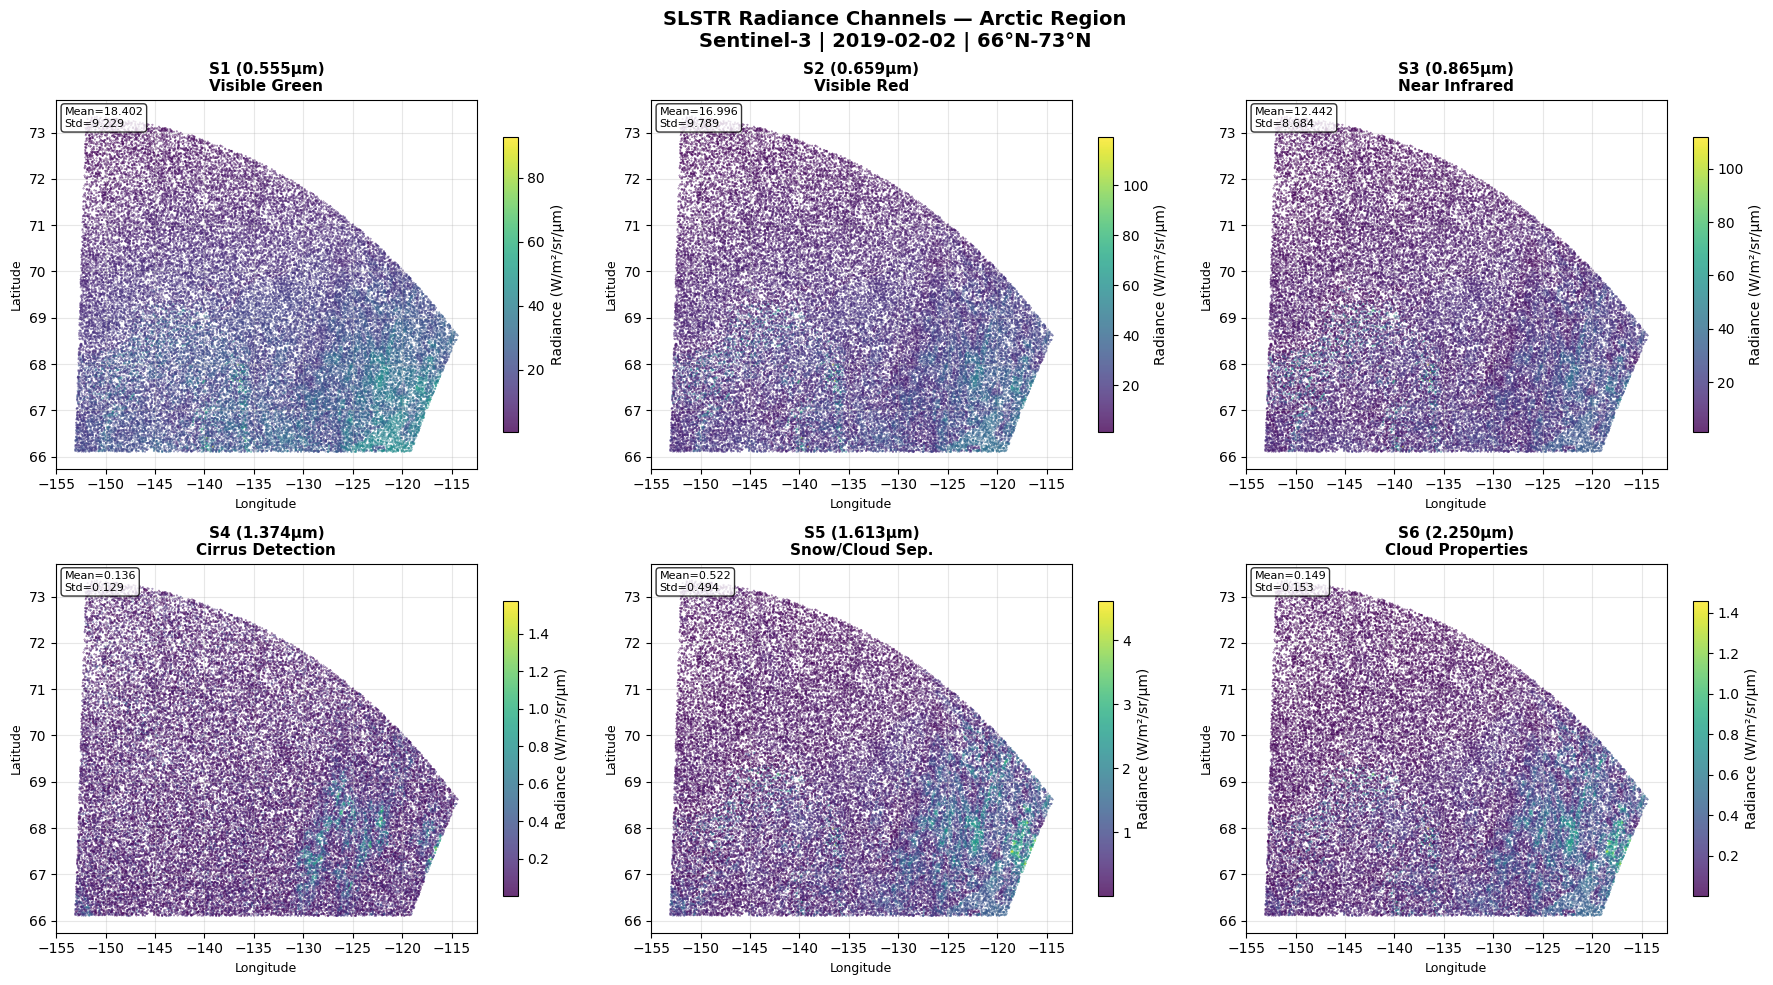

 Saved: slstr_channels_map.png


In [11]:
# The 6 SLSTR radiance channels
channels = ['S1_radiance', 'S2_radiance', 'S3_radiance',
            'S4_radiance', 'S5_radiance', 'S6_radiance']

channel_names = [
    'S1 (0.555µm)\nVisible Green',
    'S2 (0.659µm)\nVisible Red',
    'S3 (0.865µm)\nNear Infrared',
    'S4 (1.374µm)\nCirrus Detection',
    'S5 (1.613µm)\nSnow/Cloud Sep.',
    'S6 (2.250µm)\nCloud Properties'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (ch, name) in enumerate(zip(channels, channel_names)):
    ax = axes[i]

    # Plot as scatter map
    # Use sample of 50000 points for speed
    sample = data.sample(50000, random_state=42)

    sc = ax.scatter(
        sample['longitude'],
        sample['latitude'],
        c=sample[ch],
        cmap='viridis',
        s=0.1,        # tiny dots
        alpha=0.8
    )

    plt.colorbar(sc, ax=ax, shrink=0.8,
                 label='Radiance (W/m²/sr/µm)')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.grid(True, alpha=0.3)

    # Add stats
    ax.text(0.02, 0.98,
            f'Mean={data[ch].mean():.3f}\n'
            f'Std={data[ch].std():.3f}',
            transform=ax.transAxes,
            fontsize=8, va='top',
            bbox=dict(boxstyle='round',
                     facecolor='white',
                     alpha=0.8))

plt.suptitle(
    'SLSTR Radiance Channels — Arctic Region\n'
    'Sentinel-3 | 2019-02-02 | 66°N-73°N',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('slstr_channels_map.png',
            dpi=100, bbox_inches='tight')
plt.show()
print(" Saved: slstr_channels_map.png")

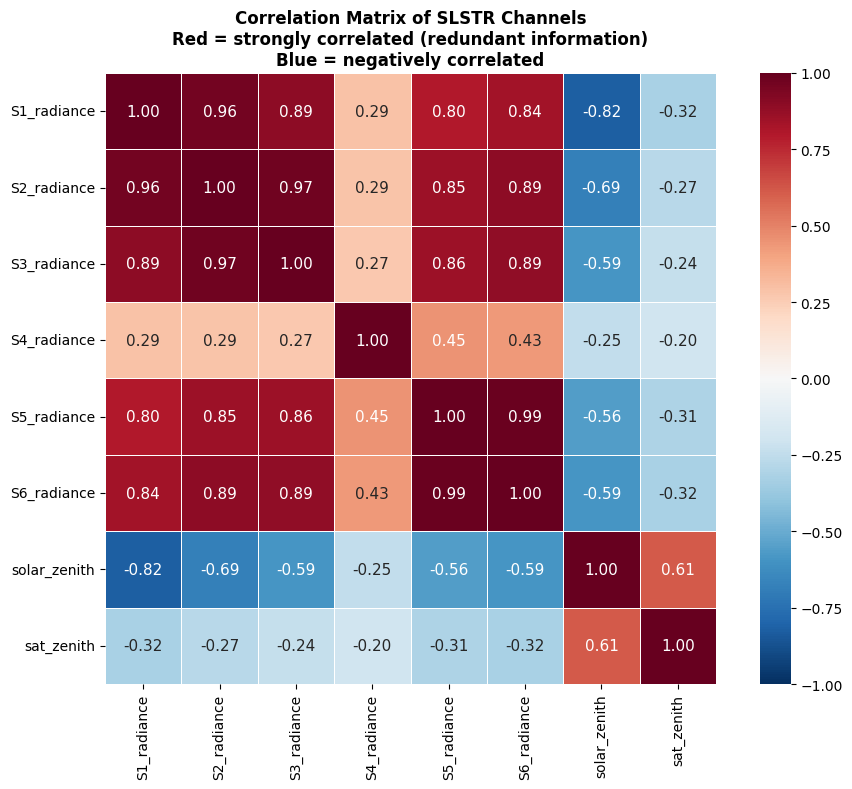


Highly correlated pairs (|r| > 0.8):
These channels contain REDUNDANT information!
  S1_radiance ↔ S2_radiance: r=0.962
  S1_radiance ↔ S3_radiance: r=0.891
  S1_radiance ↔ S5_radiance: r=0.802
  S1_radiance ↔ S6_radiance: r=0.842
  S1_radiance ↔ solar_zenith: r=-0.823
  S2_radiance ↔ S3_radiance: r=0.973
  S2_radiance ↔ S5_radiance: r=0.854
  S2_radiance ↔ S6_radiance: r=0.893
  S3_radiance ↔ S5_radiance: r=0.857
  S3_radiance ↔ S6_radiance: r=0.890
  S5_radiance ↔ S6_radiance: r=0.987

Low correlation pairs (|r| < 0.3):
These channels contain UNIQUE information!
  S1_radiance ↔ S4_radiance: r=0.292
  S2_radiance ↔ S4_radiance: r=0.289
  S2_radiance ↔ sat_zenith: r=-0.274
  S3_radiance ↔ S4_radiance: r=0.273
  S3_radiance ↔ sat_zenith: r=-0.239
  S4_radiance ↔ solar_zenith: r=-0.249
  S4_radiance ↔ sat_zenith: r=-0.200


In [12]:
# Select only the radiance channels + geometry
analysis_cols = ['S1_radiance', 'S2_radiance', 'S3_radiance',
                 'S4_radiance', 'S5_radiance', 'S6_radiance',
                 'solar_zenith', 'sat_zenith']

# Use sample for speed
sample = data[analysis_cols].sample(100000, random_state=42)

# Calculate correlation
corr = sample.corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1,
    annot_kws={'size': 11}
)

ax.set_title(
    'Correlation Matrix of SLSTR Channels\n'
    'Red = strongly correlated '
    '(redundant information)\n'
    'Blue = negatively correlated',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('correlation_matrix.png',
            dpi=100, bbox_inches='tight')
plt.show()

# Print findings
print("\nHighly correlated pairs (|r| > 0.8):")
print("These channels contain REDUNDANT information!")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            print(f"  {corr.columns[i]} ↔ "
                  f"{corr.columns[j]}: r={r:.3f}")

print("\nLow correlation pairs (|r| < 0.3):")
print("These channels contain UNIQUE information!")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) < 0.3:
            print(f"  {corr.columns[i]} ↔ "
                  f"{corr.columns[j]}: r={r:.3f}")